## Módulo 1: Diseño de Codificador y Decodificador

Este notebook implementa la primera etapa de un sistema de comunicación LoRa: la conversión entre una secuencia de bits y los símbolos numéricos.

## Objetivo

1. **Codificador**: bits a símbolos
2. **Decodificador**: símbolos a bits
3. **Verificación**: que decodificar lo codificado devuelva los bits originales
4. **Cálculo de BER** (Bit Error Rate): debe ser 0 en esta instancia

## 1. Funcionamiento

En LoRa no se transmiten bits sueltos directamente por el aire. Antes de convertir la información en una señal de radio, hay que agrupar los bits en bloques de tamaño `SF` (Spreading Factor) y representar cada bloque como un único número. Ese número es lo que llamamos `símbolo`. El codificador hace esa conversión (bits a símbolo), y el decodificador la inversa (símbolo a bits).


## 2. Librerías

In [18]:
import numpy as np
import matplotlib.pyplot as plt

## 3. Codificador

1. Verificar que la cantidad de bits sea múltiplo de `SF`.
2. Recorrer la secuencia de bits en bloques de tamaño `SF`.
3. Para cada bloque, recorrer sus bits de izquierda a derecha (MSB primero) y acumular el valor decimal usando potencias de 2 decrecientes.
4. Guardar ese valor como el símbolo correspondiente a ese bloque.


In [19]:
def codificador(bits, SF):
    """
    Convierte una secuencia de bits en símbolos LoRa.

    Parámetros
    ----------
    bits : array-like de 0s y 1s
    SF   : Spreading Factor

    Retorna
    -------
    simbolos : np.array de enteros, uno por cada bloque de SF bits
    """
    bits = np.array(bits)

    if len(bits) % SF != 0:
        raise ValueError(
            f"La cantidad de bits ({len(bits)}) debe ser múltiplo de SF ({SF})"
        )

    num_simbolos = len(bits) // SF
    simbolos = np.zeros(num_simbolos, dtype=int)

    # Recorremos cada bloque de SF bits
    for i in range(num_simbolos):
        bloque = bits[i * SF : (i + 1) * SF]

        valor = 0
        # Recorremos los bits del bloque de izquierda a derecha (MSB primero)
        for posicion, bit in enumerate(bloque):
            peso = 2 ** (SF - 1 - posicion)  # potencia de 2 decreciente
            valor += bit * peso

        simbolos[i] = valor

    return simbolos

## 4. Decodificador

1. Para cada símbolo, hay que reconstruir sus `SF` bits.
2. Recorremos las potencias de 2 de mayor a menor.
3. Convierte de decimal a binario.

In [20]:
def decodificador(simbolos, SF):
    """
    Convierte una secuencia de símbolos LoRa de vuelta a bits.

    Parámetros
    ----------
    simbolos : array-like de enteros (cada uno entre 0 y 2^SF - 1)
    SF       : Spreading Factor

    Retorna
    -------
    bits : np.array de 0s y 1s
    """
    simbolos = np.array(simbolos, dtype=int)
    num_bits = len(simbolos) * SF
    bits = np.zeros(num_bits, dtype=int)

    for i, simbolo in enumerate(simbolos):
        valor_restante = int(simbolo)

        for posicion in range(SF):
            peso = 2 ** (SF - 1 - posicion)

            if valor_restante >= peso:
                bits[i * SF + posicion] = 1
                valor_restante -= peso
            else:
                bits[i * SF + posicion] = 0

    return bits

## 5. Prueba de ejemplo

Antes de probar con datos aleatorios, conviene verificar un ejemplo:
bloque `1011` con `SF = 4` debería dar símbolo `11`, y al decodificar `11` debería devolver `1011`.


In [21]:
SF_prueba = 4
bits_prueba = np.array([1, 0, 1, 1])

simbolo_obtenido = codificador(bits_prueba, SF_prueba)
print("Bits de entrada:      ", bits_prueba)
print("Símbolo esperado:      11")
print("Símbolo obtenido:     ", simbolo_obtenido)

bits_recuperados = decodificador(simbolo_obtenido, SF_prueba)
print("\nBits recuperados:     ", bits_recuperados)
print("¿Coinciden con los originales?", np.array_equal(bits_prueba, bits_recuperados))

Bits de entrada:       [1 0 1 1]
Símbolo esperado:      11
Símbolo obtenido:      [11]

Bits recuperados:      [1 0 1 1]
¿Coinciden con los originales? True


### Prueba con varios bloques

Probamos ahora con más de un símbolo en la misma llamada, para confirmar que el recorrido por bloques funciona bien.


In [22]:
SF = 7
num_simbolos_prueba = 5
np.random.seed(42)  # reproducibilidad

bits_random = np.random.randint(0, 2, num_simbolos_prueba * SF)
print("Bits generados:", bits_random)

simbolos = codificador(bits_random, SF)
print("\nSímbolos obtenidos:", simbolos)
print("Rango válido: 0 a", 2**SF - 1)

bits_dec = decodificador(simbolos, SF)
print("\n¿Los bits decodificados son iguales a los originales?",
      np.array_equal(bits_random, bits_dec))

Bits generados: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1]

Símbolos obtenidos: [ 34  16  93  63 103]
Rango válido: 0 a 127

¿Los bits decodificados son iguales a los originales? True


## 6. Verificación exhaustiva

Conviene comprobar que el codificador-decodificador funciona para **todos los símbolos posibles** de un SF dado.

In [23]:
def verificar_todos_los_simbolos(SF):
    """
    Codifica y decodifica cada símbolo posible (de 0 a 2^SF - 1)
    representado como sus SF bits, y verifica que el resultado
    sea consistente en ambos sentidos.
    """
    N = 2 ** SF
    errores = 0

    for simbolo_original in range(N):
        # Símbolo -> bits (usamos el propio decodificador para generar el patrón de bits)
        bits_de_ese_simbolo = decodificador([simbolo_original], SF)

        # bits -> símbolo, usando el codificador
        simbolo_reconstruido = codificador(bits_de_ese_simbolo, SF)[0]

        if simbolo_reconstruido != simbolo_original:
            errores += 1
            print(f"❌ Falla en símbolo {simbolo_original}: se obtuvo {simbolo_reconstruido}")

    if errores == 0:
        print(f"✅ Los {N} símbolos posibles (SF={SF}) se codifican y decodifican correctamente.")
    else:
        print(f"Se encontraron {errores} errores de {N} símbolos.")

verificar_todos_los_simbolos(SF=7)

✅ Los 128 símbolos posibles (SF=7) se codifican y decodifican correctamente.


## 7. Cálculo de BER (Bit Error Rate)

Dado que en esta instancia aún no introdujimos ruido, el cálculo de `BER` debe resultar en `0`.

**BER = (cantidad de bits distintos) / (cantidad total de bits)**


In [24]:
def calcular_ber(bits_tx, bits_rx):
    """
    Calcula la tasa de error de bit (BER) comparando los bits transmitidos
    contra los bits recibidos/decodificados.
    """
    bits_tx = np.array(bits_tx)
    bits_rx = np.array(bits_rx)

    if len(bits_tx) != len(bits_rx):
        raise ValueError("Los vectores de bits deben tener la misma longitud")

    errores = np.sum(bits_tx != bits_rx)
    ber = errores / len(bits_tx)
    return ber

In [25]:
ber_sin_errores = calcular_ber(bits_random, bits_dec)
print("BER:", ber_sin_errores)


BER: 0.0


## 8. Visualización: bits vs símbolos

Una forma útil de entender el "spreading" es graficar los bits originales junto con los símbolos resultantes, para ver visualmente cómo cada bloque de SF bits colapsa en un solo número.


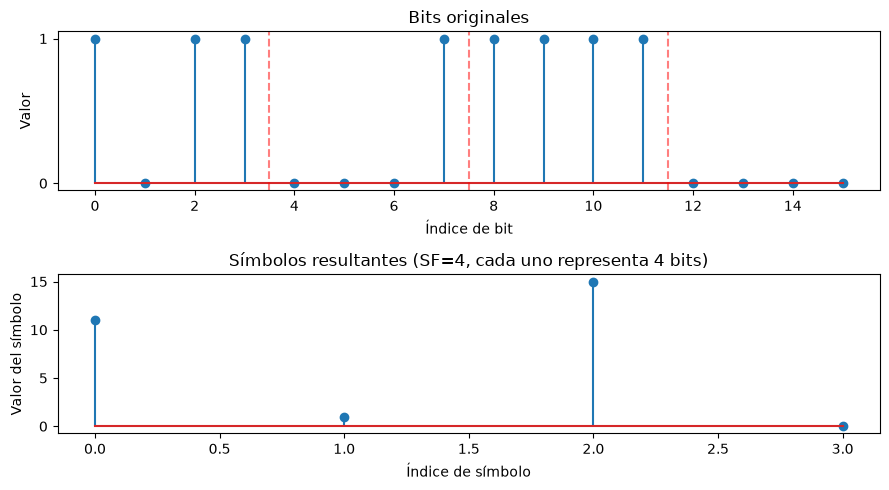

In [26]:
SF_vis = 4
bits_vis = np.array([1,0,1,1, 0,0,0,1, 1,1,1,1, 0,0,0,0])
simbolos_vis = codificador(bits_vis, SF_vis)

fig, axs = plt.subplots(2, 1, figsize=(9, 5))

axs[0].stem(bits_vis)
axs[0].set_title("Bits originales")
axs[0].set_xlabel("Índice de bit")
axs[0].set_ylabel("Valor")
axs[0].set_yticks([0, 1])

# Marcamos los límites de cada bloque de SF bits
for i in range(1, len(bits_vis) // SF_vis):
    axs[0].axvline(i * SF_vis - 0.5, color='red', linestyle='--', alpha=0.5)

axs[1].stem(simbolos_vis)
axs[1].set_title(f"Símbolos resultantes (SF={SF_vis}, cada uno representa {SF_vis} bits)")
axs[1].set_xlabel("Índice de símbolo")
axs[1].set_ylabel("Valor del símbolo")

plt.tight_layout()
plt.show()